In [1]:
# 1. Install required packages (run once in your environment / notebook)
#!pip install networkx
#!pip install python-louvain
#!pip install pyvis
#!pip install gensim

import pandas as pd
import numpy as np

import networkx as nx
import community as community_louvain

from collections import Counter
from itertools import combinations

from gensim import corpora
from gensim.models import CoherenceModel

from pyvis.network import Network

import matplotlib.pyplot as plt

from pprint import pprint

# Gensim
import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models import CoherenceModel
from gensim.models import LsiModel
from gensim.models import TfidfModel
from wordcloud import WordCloud




# spaCy for better lemmatization
import spacy

from collections import Counter
from collections import defaultdict

In [2]:
# 2. Load example data 
import pandas as pd

# Load the Amazon Electronics Reviews dataset
df = pd.read_csv("../data/processed/cleaned_reviews_latest.csv")

# Remove rows with missing review text
df = df.dropna(subset=["text"])

# Combine review title and review text (recommended)
df["review"] = df["title"].fillna("") + " " + df["text"].fillna("")

# Convert reviews to a list (same format as the demo)
data = df["review"].tolist()

print(f"Number of documents: {len(data)}")
print("Example document snippet:\n", data[0][:300], "...\n")

Number of documents: 10518
Example document snippet:
 Smells like gasoline! Going back! First & most offensive: they reek of gasoline so if you are sensitive/allergic to petroleum products like I am you will want to pass on these.  Second: the phone adapter is useless as-is. Mine was not drilled far enough to be able to tighten it into place for my iPh ...



In [3]:
# 3. Preprocessing functions
# load spacy's small lanuage model that includes Tokenizer; POS tagger (part-of-speech);
# Lemmatizer; Dependency parser; Named Entity Recognizer (NER) without building dependency tree and
# detecting and labelling named entities (performance)

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def sent_to_words(sentences):
    """Tokenize and clean basic text"""
    for sentence in sentences:
        yield gensim.utils.simple_preprocess(str(sentence), deacc=True)  # lowercase, remove punct

def remove_stopwords(texts):
    return [[word for word in gensim.utils.simple_preprocess(" ".join(doc))
             if word not in gensim.parsing.preprocessing.STOPWORDS]
            for doc in texts]

# specifying the words by their part-of-speech / grammatical category) that should be kept
def lemmatization(texts, allowed_postags=["NOUN", "ADJ", "VERB", "ADV"]):
    """Lemmatize with spaCy"""
    texts_out = []
    for sent in texts:
        doc = nlp(" ".join(sent))
        texts_out.append([token.lemma_ for token in doc
                          if token.pos_ in allowed_postags])
    return texts_out

# Apply preprocessing pipeline
data_words = list(sent_to_words(data))
data_words = remove_stopwords(data_words)
data_lemmatized = lemmatization(data_words)

print("\nExample after lemmatization:", data_lemmatized[0][:15])




Example after lemmatization: ['smell', 'gasoline', 'go', 'offensive', 'reek', 'gasoline', 'sensitive', 'allergic', 'petroleum', 'product', 'want', 'pass', 'second', 'phone', 'adapter']


In [4]:
# 5. Create Dictionary

id2word = corpora.Dictionary(data_lemmatized)

id2word.filter_extremes(
    no_below=15,
    no_above=0.50
)

print(id2word)
# Use the filtered dictionary as the single vocabulary
vocabulary = set(id2word.token2id.keys())

print(f"Final vocabulary size: {len(vocabulary)}")


Dictionary<2032 unique tokens: ['able', 'accessory', 'adapter', 'average', 'binocular']...>
Final vocabulary size: 2032


In [5]:
# FILTER VOCABULARY 
custom_stopwords = {
    "good", "great", "nice", "love", "work",
    "get", "come", "make", "thing", "use",
    "really", "well", "little", "buy",
    "want", "try", "new", "product",
    "recommend", "take", "look", "ve"
}

filtered_docs = []

for doc in data_lemmatized:

    filtered = [
        word
        for word in doc
        if word in vocabulary
        and word not in custom_stopwords
    ]

    if len(filtered) >= 2:
        filtered_docs.append(filtered)

print(f"Documents retained for graph construction: {len(filtered_docs)}")

Documents retained for graph construction: 10049


In [6]:
# 6. Build Graph-of-Words

window_size = 4

G = nx.Graph()

for doc in filtered_docs:

    for i in range(len(doc)):

        for j in range(i + 1, min(i + window_size, len(doc))):

            w1 = doc[i]
            w2 = doc[j]

            if w1 == w2:
                continue

            if G.has_edge(w1, w2):

                G[w1][w2]["weight"] += 1

            else:

                G.add_edge(
                    w1,
                    w2,
                    weight=1
                )

print("Nodes :", G.number_of_nodes())
print("Edges :", G.number_of_edges())

Nodes : 2011
Edges : 292084


In [ ]:
# ============================================
# Window Size Sensitivity Analysis
# ============================================

import time
import networkx as nx
import community.community_louvain as community_louvain
from collections import defaultdict
from gensim.models import CoherenceModel


window_sizes = [2, 4, 6]

window_results = []


for window_size in window_sizes:

    print("\n" + "=" * 60)
    print(f"TESTING WINDOW SIZE: {window_size}")
    print("=" * 60)

    # Start timer
    start_time = time.time()

    # ----------------------------------------
    # 1. Build Graph-of-Words
    # ----------------------------------------

    G_test = nx.Graph()

    for doc in filtered_docs:

        for i in range(len(doc)):

            for j in range(
                i + 1,
                min(i + window_size, len(doc))
            ):

                w1 = doc[i]
                w2 = doc[j]

                if w1 == w2:
                    continue

                if G_test.has_edge(w1, w2):
                    G_test[w1][w2]["weight"] += 1

                else:
                    G_test.add_edge(
                        w1,
                        w2,
                        weight=1
                    )

    # ----------------------------------------
    # 2. Louvain Community Detection
    # ----------------------------------------

    partition_test = community_louvain.best_partition(
        G_test,
        weight="weight",
        random_state=42
    )

    number_of_communities = len(
        set(partition_test.values())
    )

    # ----------------------------------------
    # 3. Modularity
    # ----------------------------------------

    modularity_test = community_louvain.modularity(
        partition_test,
        G_test,
        weight="weight"
    )

    # ----------------------------------------
    # 4. PageRank
    # ----------------------------------------

    pagerank_test = nx.pagerank(
        G_test,
        weight="weight"
    )

    # ----------------------------------------
    # 5. Extract topic words
    # ----------------------------------------

    topics_test = defaultdict(list)

    for word, community in partition_test.items():
        topics_test[community].append(word)

    topic_words_test = []

    MIN_COMMUNITY_SIZE = 8
    TOP_WORDS = 15

    for community_id in sorted(topics_test.keys()):

        ranked_words = sorted(
            topics_test[community_id],
            key=lambda word: pagerank_test[word],
            reverse=True
        )

        if len(ranked_words) >= MIN_COMMUNITY_SIZE:

            topic_words_test.append(
                ranked_words[:TOP_WORDS]
            )

    # ----------------------------------------
    # 6. Coherence
    # ----------------------------------------

    coherence_model_test = CoherenceModel(
        topics=topic_words_test,
        texts=data_lemmatized,
        dictionary=id2word,
        coherence="c_v"
    )

    coherence_test = (
        coherence_model_test.get_coherence()
    )

    # ----------------------------------------
    # 7. Training time
    # ----------------------------------------

    training_time = time.time() - start_time

    # ----------------------------------------
    # 8. Store results
    # ----------------------------------------

    window_results.append({
        "Window Size": window_size,
        "Nodes": G_test.number_of_nodes(),
        "Edges": G_test.number_of_edges(),
        "Communities": number_of_communities,
        "Modularity": modularity_test,
        "Coherence": coherence_test,
        "Training Time (seconds)": training_time
    })

    # ----------------------------------------
    # 9. Print results
    # ----------------------------------------

    print(f"Nodes: {G_test.number_of_nodes()}")
    print(f"Edges: {G_test.number_of_edges()}")
    print(f"Communities: {number_of_communities}")
    print(f"Modularity: {modularity_test:.4f}")
    print(f"Coherence (c_v): {coherence_test:.4f}")
    print(f"Training Time: {training_time:.2f} seconds")


# Convert results to DataFrame

window_results_df = pd.DataFrame(window_results)

print("\n")
print("=" * 60)
print("WINDOW SIZE COMPARISON")
print("=" * 60)

display(window_results_df)


TESTING WINDOW SIZE: 2
Nodes: 2011
Edges: 129737
Communities: 8
Modularity: 0.1720
Coherence (c_v): 0.4510
Training Time: 21.94 seconds

TESTING WINDOW SIZE: 4
Nodes: 2011
Edges: 292084
Communities: 6
Modularity: 0.1335
Coherence (c_v): 0.4766
Training Time: 31.62 seconds

TESTING WINDOW SIZE: 6
Nodes: 2011
Edges: 396773
Communities: 6
Modularity: 0.1215
Coherence (c_v): 0.4409
Training Time: 41.42 seconds


WINDOW SIZE COMPARISON


,Window Size,Nodes,Edges,Communities,Modularity,Coherence,Training Time (seconds)
0,2,2011,129737,8,0.171965,0.451040,21.940762
1,4,2011,292084,6,0.133504,0.476581,31.617811
2,6,2011,396773,6,0.121507,0.440918,41.424178


In [8]:
# 7. Detect Communities

partition = community_louvain.best_partition(
    G,
    weight="weight",
    random_state=42
)

print("Number of Communities:",
      len(set(partition.values())))

Number of Communities: 6


In [9]:
# ============================================
# Louvain Community Detection
# ============================================

partition = community_louvain.best_partition(
    G,
    weight="weight",
    random_state=42
)

# Number of detected communities
num_communities = len(set(partition.values()))

# Calculate modularity
modularity_score = community_louvain.modularity(
    partition,
    G,
    weight="weight"
)

print(f"Number of communities: {num_communities}")
print(f"Modularity: {modularity_score:.4f}")

Number of communities: 6
Modularity: 0.1335


In [10]:
pagerank_scores = nx.pagerank(
    G,
    weight="weight"
)

In [11]:
from collections import defaultdict
topics = defaultdict(list)

MIN_COMMUNITY_SIZE = 8
TOP_WORDS = 15

for word, community in partition.items():

    topics[community].append(word)

topic_words = []

for community_id in sorted(topics.keys()):

    ranked = sorted(
        topics[community_id],
        key=lambda word: pagerank_scores[word],
        reverse=True
    )

    # Ignore very small communities
    if len(ranked) >= MIN_COMMUNITY_SIZE:
        topic_words.append(ranked[:TOP_WORDS])
        print(f"\nTopic {community_id} ({len(ranked)} words)")
        print(ranked[:TOP_WORDS])


Topic 0 (526 words)
['case', 'small', 'fit', 'laptop', 'screen', 'hold', 'perfect', 'way', 'size', 'ipad', 'cover', 'right', 'bag', 'bit', 'feel']

Topic 1 (432 words)
['time', 'review', 'purchase', 'go', 'year', 'think', 'old', 'day', 'know', 'unit', 'say', 'read', 'help', 'provide', 'update']

Topic 2 (152 words)
['need', 'cable', 'charge', 'battery', 'long', 'plug', 'power', 'cord', 'port', 'fast', 'include', 'end', 'add', 'hour', 'charger']

Topic 3 (281 words)
['easy', 'set', 'device', 'issue', 'connect', 'drive', 'problem', 'button', 'able', 'card', 'hard', 'home', 'run', 'start', 'app']

Topic 4 (281 words)
['camera', 'light', 'lot', 'br', 'picture', 'tv', 'video', 'feature', 'color', 'watch', 'room', 'different', 'allow', 'remote', 'monitor']

Topic 5 (339 words)
['sound', 'quality', 'phone', 'price', 'speaker', 'headphone', 'far', 'turn', 'music', 'high', 'play', 'expect', 'ear', 'fine', 'pair']


In [12]:
# 10. Compute Topic Coherence

coherence_model_graph = CoherenceModel(
    topics=topic_words,
    texts=data_lemmatized,
    dictionary=id2word,
    coherence="c_v"
)

coherence_graph = coherence_model_graph.get_coherence()

print(f"\nGraph-Based Coherence Score (c_v): {coherence_graph:.4f}")


Graph-Based Coherence Score (c_v): 0.4766


In [13]:
# GRAPH STATISTICS

import networkx as nx
import numpy as np
from collections import Counter

print("=" * 50)
print("GRAPH STATISTICS")
print("=" * 50)

# Basic Graph Statistics
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)
avg_degree = np.mean([deg for _, deg in G.degree()])
num_components = nx.number_connected_components(G)

print(f"Number of Nodes          : {num_nodes}")
print(f"Number of Edges          : {num_edges}")
print(f"Graph Density            : {density:.6f}")
print(f"Average Degree           : {avg_degree:.2f}")
print(f"Connected Components     : {num_components}")

print("\n" + "=" * 50)

# Community Statistics
community_sizes = Counter(partition.values())

num_communities = len(community_sizes)
largest_community = max(community_sizes.values())
smallest_community = min(community_sizes.values())
avg_community_size = np.mean(list(community_sizes.values()))

print("COMMUNITY STATISTICS")
print("=" * 50)

print(f"Number of Communities    : {num_communities}")
print(f"Largest Community        : {largest_community} words")
print(f"Smallest Community       : {smallest_community} words")
print(f"Average Community Size   : {avg_community_size:.2f} words")

GRAPH STATISTICS
Number of Nodes          : 2011
Number of Edges          : 292084
Graph Density            : 0.144521
Average Degree           : 290.49
Connected Components     : 1

COMMUNITY STATISTICS
Number of Communities    : 6
Largest Community        : 526 words
Smallest Community       : 152 words
Average Community Size   : 335.17 words


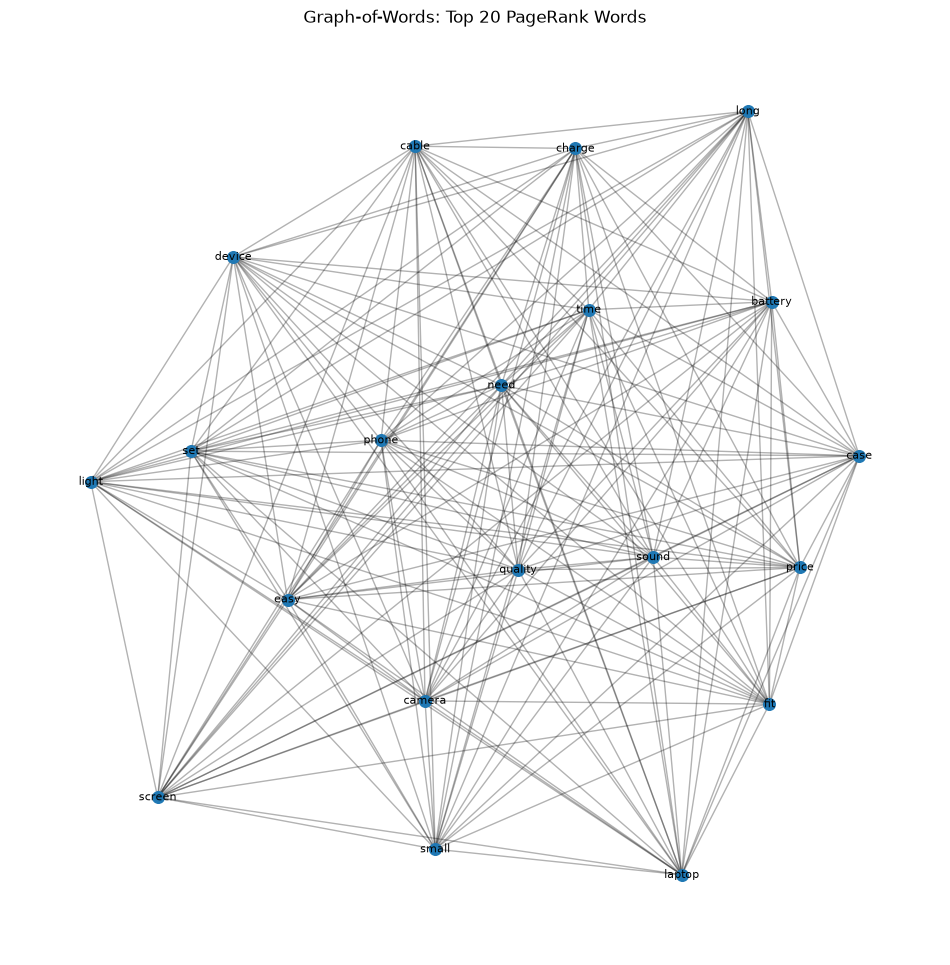

In [14]:
top_nodes = sorted(
    pagerank_scores,
    key=pagerank_scores.get,
    reverse=True
)[:20]

subgraph = G.subgraph(top_nodes)

plt.figure(figsize=(12, 12))

pos = nx.spring_layout(
    subgraph,
    seed=42
)

nx.draw_networkx_nodes(
    subgraph,
    pos,
    node_size=70
)

nx.draw_networkx_edges(
    subgraph,
    pos,
    alpha=0.3
)

nx.draw_networkx_labels(
    subgraph,
    pos,
    font_size=8
)

plt.title("Graph-of-Words: Top 20 PageRank Words")
plt.axis("off")
plt.show()

In [15]:
topic_df = pd.DataFrame({
    "Topic": range(len(topic_words)),
    "Keywords": [", ".join(words) for words in topic_words]
})

topic_df.to_csv("graph_topics.csv", index=False)

topic_df.head()

,Topic,Keywords
0,0,"case, small, fit, laptop, screen, hold, perfec..."
1,1,"time, review, purchase, go, year, think, old, ..."
2,2,"need, cable, charge, battery, long, plug, powe..."
3,3,"easy, set, device, issue, connect, drive, prob..."
4,4,"camera, light, lot, br, picture, tv, video, fe..."


In [16]:
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Communities:", len(set(partition.values())))

edge_weights = [d["weight"] for _, _, d in G.edges(data=True)]
print("Maximum edge weight:", max(edge_weights))

Nodes: 2011
Edges: 292084
Communities: 6
Maximum edge weight: 618


In [18]:
# ============================================
# Graph-Based Model Computational Performance
# Final Configuration
# ============================================

import time
import os
import psutil
import networkx as nx
import community.community_louvain as community_louvain
from collections import defaultdict
from gensim.models import CoherenceModel

# Final selected configuration
window_size = 4
random_state = 42

process = psutil.Process(os.getpid())

# Memory before execution
memory_before = process.memory_info().rss / (1024 ** 2)

total_start = time.time()


# --------------------------------------------
# 1. Graph Construction
# --------------------------------------------

graph_start = time.time()

G = nx.Graph()

for doc in filtered_docs:

    for i in range(len(doc)):

        for j in range(
            i + 1,
            min(i + window_size, len(doc))
        ):

            w1 = doc[i]
            w2 = doc[j]

            if w1 == w2:
                continue

            if G.has_edge(w1, w2):
                G[w1][w2]["weight"] += 1
            else:
                G.add_edge(
                    w1,
                    w2,
                    weight=1
                )

graph_time = time.time() - graph_start


# --------------------------------------------
# 2. Louvain Community Detection
# --------------------------------------------

community_start = time.time()

partition = community_louvain.best_partition(
    G,
    weight="weight",
    random_state=random_state
)

community_time = time.time() - community_start


# --------------------------------------------
# 3. Community Statistics
# --------------------------------------------

number_of_communities = len(
    set(partition.values())
)

modularity_score = community_louvain.modularity(
    partition,
    G,
    weight="weight"
)


# --------------------------------------------
# 4. PageRank
# --------------------------------------------

pagerank_start = time.time()

pagerank_scores = nx.pagerank(
    G,
    weight="weight"
)

pagerank_time = time.time() - pagerank_start


# --------------------------------------------
# 5. Extract Topic Words
# --------------------------------------------

topics = defaultdict(list)

for word, community in partition.items():
    topics[community].append(word)

topic_words = []

for community_id in sorted(topics.keys()):

    ranked_words = sorted(
        topics[community_id],
        key=lambda word: pagerank_scores[word],
        reverse=True
    )

    if len(ranked_words) >= 8:
        topic_words.append(
            ranked_words[:15]
        )


# --------------------------------------------
# 6. Coherence
# --------------------------------------------

coherence_start = time.time()

coherence_model = CoherenceModel(
    topics=topic_words,
    texts=data_lemmatized,
    dictionary=id2word,
    coherence="c_v"
)

coherence_score = coherence_model.get_coherence()

coherence_time = time.time() - coherence_start


# --------------------------------------------
# 7. Total Execution Time
# --------------------------------------------

total_time = time.time() - total_start


# --------------------------------------------
# 8. Memory
# --------------------------------------------

memory_after = process.memory_info().rss / (1024 ** 2)

memory_used = memory_after - memory_before


# --------------------------------------------
# 9. Final Results
# --------------------------------------------

computational_results = pd.DataFrame([{

    "Window Size": window_size,
    "Vocabulary Size": len(vocabulary),
    "Nodes": G.number_of_nodes(),
    "Edges": G.number_of_edges(),
    "Communities": number_of_communities,
    "Modularity": modularity_score,
    "Coherence": coherence_score,
    "Graph Construction (sec)": graph_time,
    "Community Detection (sec)": community_time,
    "PageRank (sec)": pagerank_time,
    "Coherence Calculation (sec)": coherence_time,
    "Total Execution Time (sec)": total_time,
    "Memory Used (MB)": memory_used

}])

display(computational_results)

,Window Size,Vocabulary Size,Nodes,Edges,Communities,Modularity,Coherence,Graph Construction (sec),Community Detection (sec),PageRank (sec),Coherence Calculation (sec),Total Execution Time (sec),Memory Used (MB)
0,4,2032,2011,292084,6,0.133504,0.476581,4.041354,19.611928,2.202454,7.46554,34.639753,-3.257812


In [19]:
# ============================================
# GRAPH-BASED MODEL SCALABILITY TEST
# ============================================

import time
import os
import psutil
import networkx as nx
import community.community_louvain as community_louvain
from collections import defaultdict
from gensim.models import CoherenceModel

# Final configuration
window_size = 4
random_state = 42

# Dataset sizes to test
dataset_sizes = [2000, 5000, 7500, 10518]

# Process for memory measurement
process = psutil.Process(os.getpid())

scalability_results = []


for dataset_size in dataset_sizes:

    print("\n" + "=" * 65)
    print(f"GRAPH-BASED SCALABILITY TEST: {dataset_size} REVIEWS")
    print("=" * 65)

    # ----------------------------------------
    # Select subset
    # ----------------------------------------

    subset_docs = filtered_docs[:dataset_size]

    # Memory before execution
    memory_before = (
        process.memory_info().rss / (1024 ** 2)
    )

    total_start = time.time()


    # ========================================
    # 1. Graph Construction
    # ========================================

    graph_start = time.time()

    G_scale = nx.Graph()

    for doc in subset_docs:

        for i in range(len(doc)):

            for j in range(
                i + 1,
                min(i + window_size, len(doc))
            ):

                w1 = doc[i]
                w2 = doc[j]

                if w1 == w2:
                    continue

                if G_scale.has_edge(w1, w2):

                    G_scale[w1][w2]["weight"] += 1

                else:

                    G_scale.add_edge(
                        w1,
                        w2,
                        weight=1
                    )

    graph_time = time.time() - graph_start


    # ========================================
    # 2. Louvain Community Detection
    # ========================================

    community_start = time.time()

    partition_scale = (
        community_louvain.best_partition(
            G_scale,
            weight="weight",
            random_state=random_state
        )
    )

    community_time = (
        time.time() - community_start
    )


    # ========================================
    # 3. Community Statistics
    # ========================================

    number_of_communities = len(
        set(partition_scale.values())
    )

    modularity_score = (
        community_louvain.modularity(
            partition_scale,
            G_scale,
            weight="weight"
        )
    )


    # ========================================
    # 4. PageRank
    # ========================================

    pagerank_start = time.time()

    pagerank_scores_scale = nx.pagerank(
        G_scale,
        weight="weight"
    )

    pagerank_time = (
        time.time() - pagerank_start
    )


    # ========================================
    # 5. Extract Topic Words
    # ========================================

    topics_scale = defaultdict(list)

    for word, community in partition_scale.items():

        topics_scale[community].append(word)


    topic_words_scale = []

    for community_id in sorted(
        topics_scale.keys()
    ):

        ranked_words = sorted(
            topics_scale[community_id],
            key=lambda word: pagerank_scores_scale[word],
            reverse=True
        )

        if len(ranked_words) >= 8:

            topic_words_scale.append(
                ranked_words[:15]
            )


    # ========================================
    # 6. Coherence
    # ========================================

    coherence_start = time.time()

    coherence_model_scale = CoherenceModel(
        topics=topic_words_scale,
        texts=subset_docs,
        dictionary=id2word,
        coherence="c_v"
    )

    coherence_score = (
        coherence_model_scale.get_coherence()
    )

    coherence_time = (
        time.time() - coherence_start
    )


    # ========================================
    # 7. Total Execution Time
    # ========================================

    total_time = (
        time.time() - total_start
    )


    # ========================================
    # 8. Memory
    # ========================================

    memory_after = (
        process.memory_info().rss / (1024 ** 2)
    )

    memory_used = (
        memory_after - memory_before
    )


    # ========================================
    # 9. Vocabulary Size
    # ========================================

    subset_vocabulary = set(
        word
        for doc in subset_docs
        for word in doc
    )


    # ========================================
    # 10. Store Results
    # ========================================

    scalability_results.append({

        "Reviews": dataset_size,

        "Vocabulary Size":
            len(subset_vocabulary),

        "Nodes":
            G_scale.number_of_nodes(),

        "Edges":
            G_scale.number_of_edges(),

        "Communities":
            number_of_communities,

        "Modularity":
            modularity_score,

        "Coherence":
            coherence_score,

        "Graph Time (sec)":
            graph_time,

        "Community Time (sec)":
            community_time,

        "PageRank Time (sec)":
            pagerank_time,

        "Coherence Time (sec)":
            coherence_time,

        "Total Time (sec)":
            total_time,

        "Memory Used (MB)":
            memory_used
    })


    # ========================================
    # 11. Print Results
    # ========================================

    print(f"Vocabulary Size:       {len(subset_vocabulary)}")
    print(f"Nodes:                 {G_scale.number_of_nodes()}")
    print(f"Edges:                 {G_scale.number_of_edges()}")
    print(f"Communities:           {number_of_communities}")
    print(f"Modularity:            {modularity_score:.4f}")
    print(f"Coherence (c_v):       {coherence_score:.4f}")
    print(f"Graph Time:            {graph_time:.2f} seconds")
    print(f"Community Time:        {community_time:.2f} seconds")
    print(f"PageRank Time:         {pagerank_time:.2f} seconds")
    print(f"Coherence Time:        {coherence_time:.2f} seconds")
    print(f"Total Execution Time:  {total_time:.2f} seconds")
    print(f"Memory Used:           {memory_used:.2f} MB")


# ============================================
# Final Scalability Table
# ============================================

scalability_df = pd.DataFrame(
    scalability_results
)

print("\n")
print("=" * 65)
print("GRAPH-BASED SCALABILITY RESULTS")
print("=" * 65)

display(scalability_df)


GRAPH-BASED SCALABILITY TEST: 2000 REVIEWS
Vocabulary Size:       1940
Nodes:                 1940
Edges:                 71549
Communities:           8
Modularity:            0.1641
Coherence (c_v):       0.4659
Graph Time:            1.37 seconds
Community Time:        7.45 seconds
PageRank Time:         0.30 seconds
Coherence Time:        5.45 seconds
Total Execution Time:  14.87 seconds
Memory Used:           12.80 MB

GRAPH-BASED SCALABILITY TEST: 5000 REVIEWS
Vocabulary Size:       2011
Nodes:                 2011
Edges:                 200099
Communities:           6
Modularity:            0.1412
Coherence (c_v):       0.4977
Graph Time:            2.23 seconds
Community Time:        17.53 seconds
PageRank Time:         1.92 seconds
Coherence Time:        5.69 seconds
Total Execution Time:  28.18 seconds
Memory Used:           49.74 MB

GRAPH-BASED SCALABILITY TEST: 7500 REVIEWS
Vocabulary Size:       2011
Nodes:                 2011
Edges:                 263156
Communities:  

,Reviews,Vocabulary Size,Nodes,Edges,Communities,Modularity,Coherence,Graph Time (sec),Community Time (sec),PageRank Time (sec),Coherence Time (sec),Total Time (sec),Memory Used (MB)
0,2000,1940,1940,71549,8,0.164106,0.465920,1.371287,7.451112,0.298249,5.445768,14.870935,12.800781
1,5000,2011,2011,200099,6,0.141195,0.497728,2.228468,17.528154,1.917880,5.686909,28.175898,49.738281
2,7500,2011,2011,263156,7,0.138083,0.474179,3.057287,19.589919,1.888796,6.062788,31.701132,-9.597656
3,10518,2011,2011,292084,6,0.133504,0.509146,3.654616,18.099563,2.631068,5.849020,31.426386,46.746094
